# Traitement de l'EUEMr
Ce Notebook qui permet générer le réseau baysien basé sur les données de l'EUEMr

## Table des matières
- [Formatage de l'EUEMr](#PreTraitement)
- [Création du BN](#Creation)
- [Test](#Test)

In [1]:
"""
Created on 26-06-2025

@author: cv1751 - Brice Le Lostec
@description: Class for generating Bayesian Networks (BN) using pyAgrum.
@note: This class provides methods to save, load, plot Bayesian Networks and load CSV files.
@version: 1.0
python 3.11

"""
import numpy as np
import pandas as pd
import sys
import os
import yaml

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.Master_genereBN import Master_genereBN
from EUEMr import FormatageEUEMr, EUEMr

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# PreTraitement
Creer un fichier csv formaté avec les colonnes d'intérêt de l'EUEMr, lesquelles sont transformées

In [2]:
# Creer un fichier csv formaté avec les colonnes d'intérêt
InsClsSondage = FormatageEUEMr()
InsClsSondage.Main()
#InsClsSondage.get_Mettadata()


DataFrame saved to n:\Mes Documents\Projets LTE\Projet archQc\code\GITHUB_Repo\LTE-Sampler-Residential//data//EUEMr//2022//sondage_residentiel_version_finale_formatted.csv.


# Création
Création d'un réseau bayesien

In [3]:
import pyagrum as gum
gum.availableBNExts()

'bif|dsl|net|bifxml|o3prm|uai|xdsl|pkl'

In [4]:
#import pyagrum
#gum.availableBNExts()

InsClsEUEMr = EUEMr()
InsClsEUEMr.Make_csv()
InsClsEUEMr.Make_BN()

path = "../data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr.Save_BN(path)

#save Structure
dict_info = {}
for node_c_id in InsClsEUEMr.LIST_Dict:
    # Get the variable object from the node ID
    retrieved_var = InsClsEUEMr.bn.variable(node_c_id)
    dict_info[node_c_id] = {"id":InsClsEUEMr.bn.idFromName(node_c_id),
                            "Nom":retrieved_var.name(),
                            "Description":retrieved_var.description(),
                            "Valeurs":list(retrieved_var.labels()),
                            "Dépendance (parents)": [InsClsEUEMr.bn.variable(i).name() for i in list(InsClsEUEMr.bn.parents(node_c_id))],
                            "Dépendance (enfants)": [InsClsEUEMr.bn.variable(i).name() for i in list(InsClsEUEMr.bn.children(node_c_id))],
                            "Échantillonneur": "Réseau Bayesien",
                            "Source": "EUEMR modifié"}
with open("../dataStructure/Bn.yml", 'w') as outfile:
    #yaml.dump([InsClsEUEMr.NOEUD_EUEMr, InsClsEUEMr.LIST_Dict], outfile, default_flow_style=False)
    yaml.safe_dump([InsClsEUEMr.NOEUD_EUEMr, InsClsEUEMr.LIST_Dict,dict_info], outfile, default_flow_style=False)

In [5]:
with open("../dataStructure/Bn.yml", 'r') as file:
        NOEUD_EUEMr, LIST_Dict, dict_info = yaml.safe_load(file)
pdDescription = pd.DataFrame.from_dict(dict_info).T.set_index("id").sort_index().reset_index()[["id", "Nom", "Description", "Valeurs", "Dépendance (parents)","Dépendance (enfants)", "Échantillonneur", "Source"]]
#pdDescription["Échantillonneur"] = "Réseau Bayesien"
#pdDescription["Source"] = "EUEMR"
pdDescription.to_csv("../dataStructure/Bn.csv", index=False)
pdDescription

,id,Nom,Description,Valeurs,Dépendance (parents),Dépendance (enfants),Échantillonneur,Source
0,0,Territoire_HQ,Territoire HQ,"[Est et Nord du Québec, Laurentides, Montmoren...",[],"[Region_Administrative, Source_Energie_Chauf]",Réseau Bayesien,EUEMR modifié
1,1,Region_Administrative,Zone du Québec,"[Bas-Saint-Laurent, Capitale-Nationale, Centre...",[Territoire_HQ],"[Type_Logement, Nombre_Etages, Spa_Presence, P...",Réseau Bayesien,EUEMR modifié
2,2,Type_Logement,De quel genre d'habitation s'agit-il?,"[Collective, Triplex, Duplex, Maison en rangee...",[Region_Administrative],"[Type_Batiment, Nombre_Etages, Nombre_Pieces, ...",Réseau Bayesien,EUEMR modifié
3,3,Type_Batiment,De quel genre d'habitation s'agit-il?,"[Collective, Plex, Maison]",[Type_Logement],[Source_Energie_Chauf],Réseau Bayesien,EUEMR modifié
4,4,Nombre_Etages,Nombre d'étages habitables dans la résidence (...,"[Un étage, Deux étages, Trois étages et plus]","[Region_Administrative, Type_Logement]","[Nombre_Pieces, Presence_SousSol]",Réseau Bayesien,EUEMR modifié
5,5,Nombre_Pieces,Nombre de pièces dans la résidence (incluant l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[Type_Logement, Nombre_Etages]","[Nombre_Personnes, Superficie_Totale]",Réseau Bayesien,EUEMR modifié
6,6,Superficie_Totale,Quelle est la superficie TOTALE habitable de v...,"[[1 - 500), [500 - 1000), [1000 - 1500), [1500...",[Nombre_Pieces],[],Réseau Bayesien,EUEMR modifié
7,7,Presence_SousSol,Votre résidence comporte-elle un sous-sol ou v...,"[Sous sol 6 pied, Vide sanitaire moins 6 pieds...","[Type_Logement, Nombre_Etages]",[],Réseau Bayesien,EUEMR modifié
8,8,Nombre_Personnes,"En vous incluant, combien de personnes habiten...","[1, 2, 3, 4, 5 et plus]",[Nombre_Pieces],"[Congelateur_Nombre, Refrigerateur_Nombre, Lav...",Réseau Bayesien,EUEMR modifié
9,9,Presence_Garage,Avez-vous un garage?,"[Pas de Garage, Garage non chauffé, Garage cha...",[Type_Logement],[],Réseau Bayesien,EUEMR modifié


# Test
Test du réseau bayesien créé

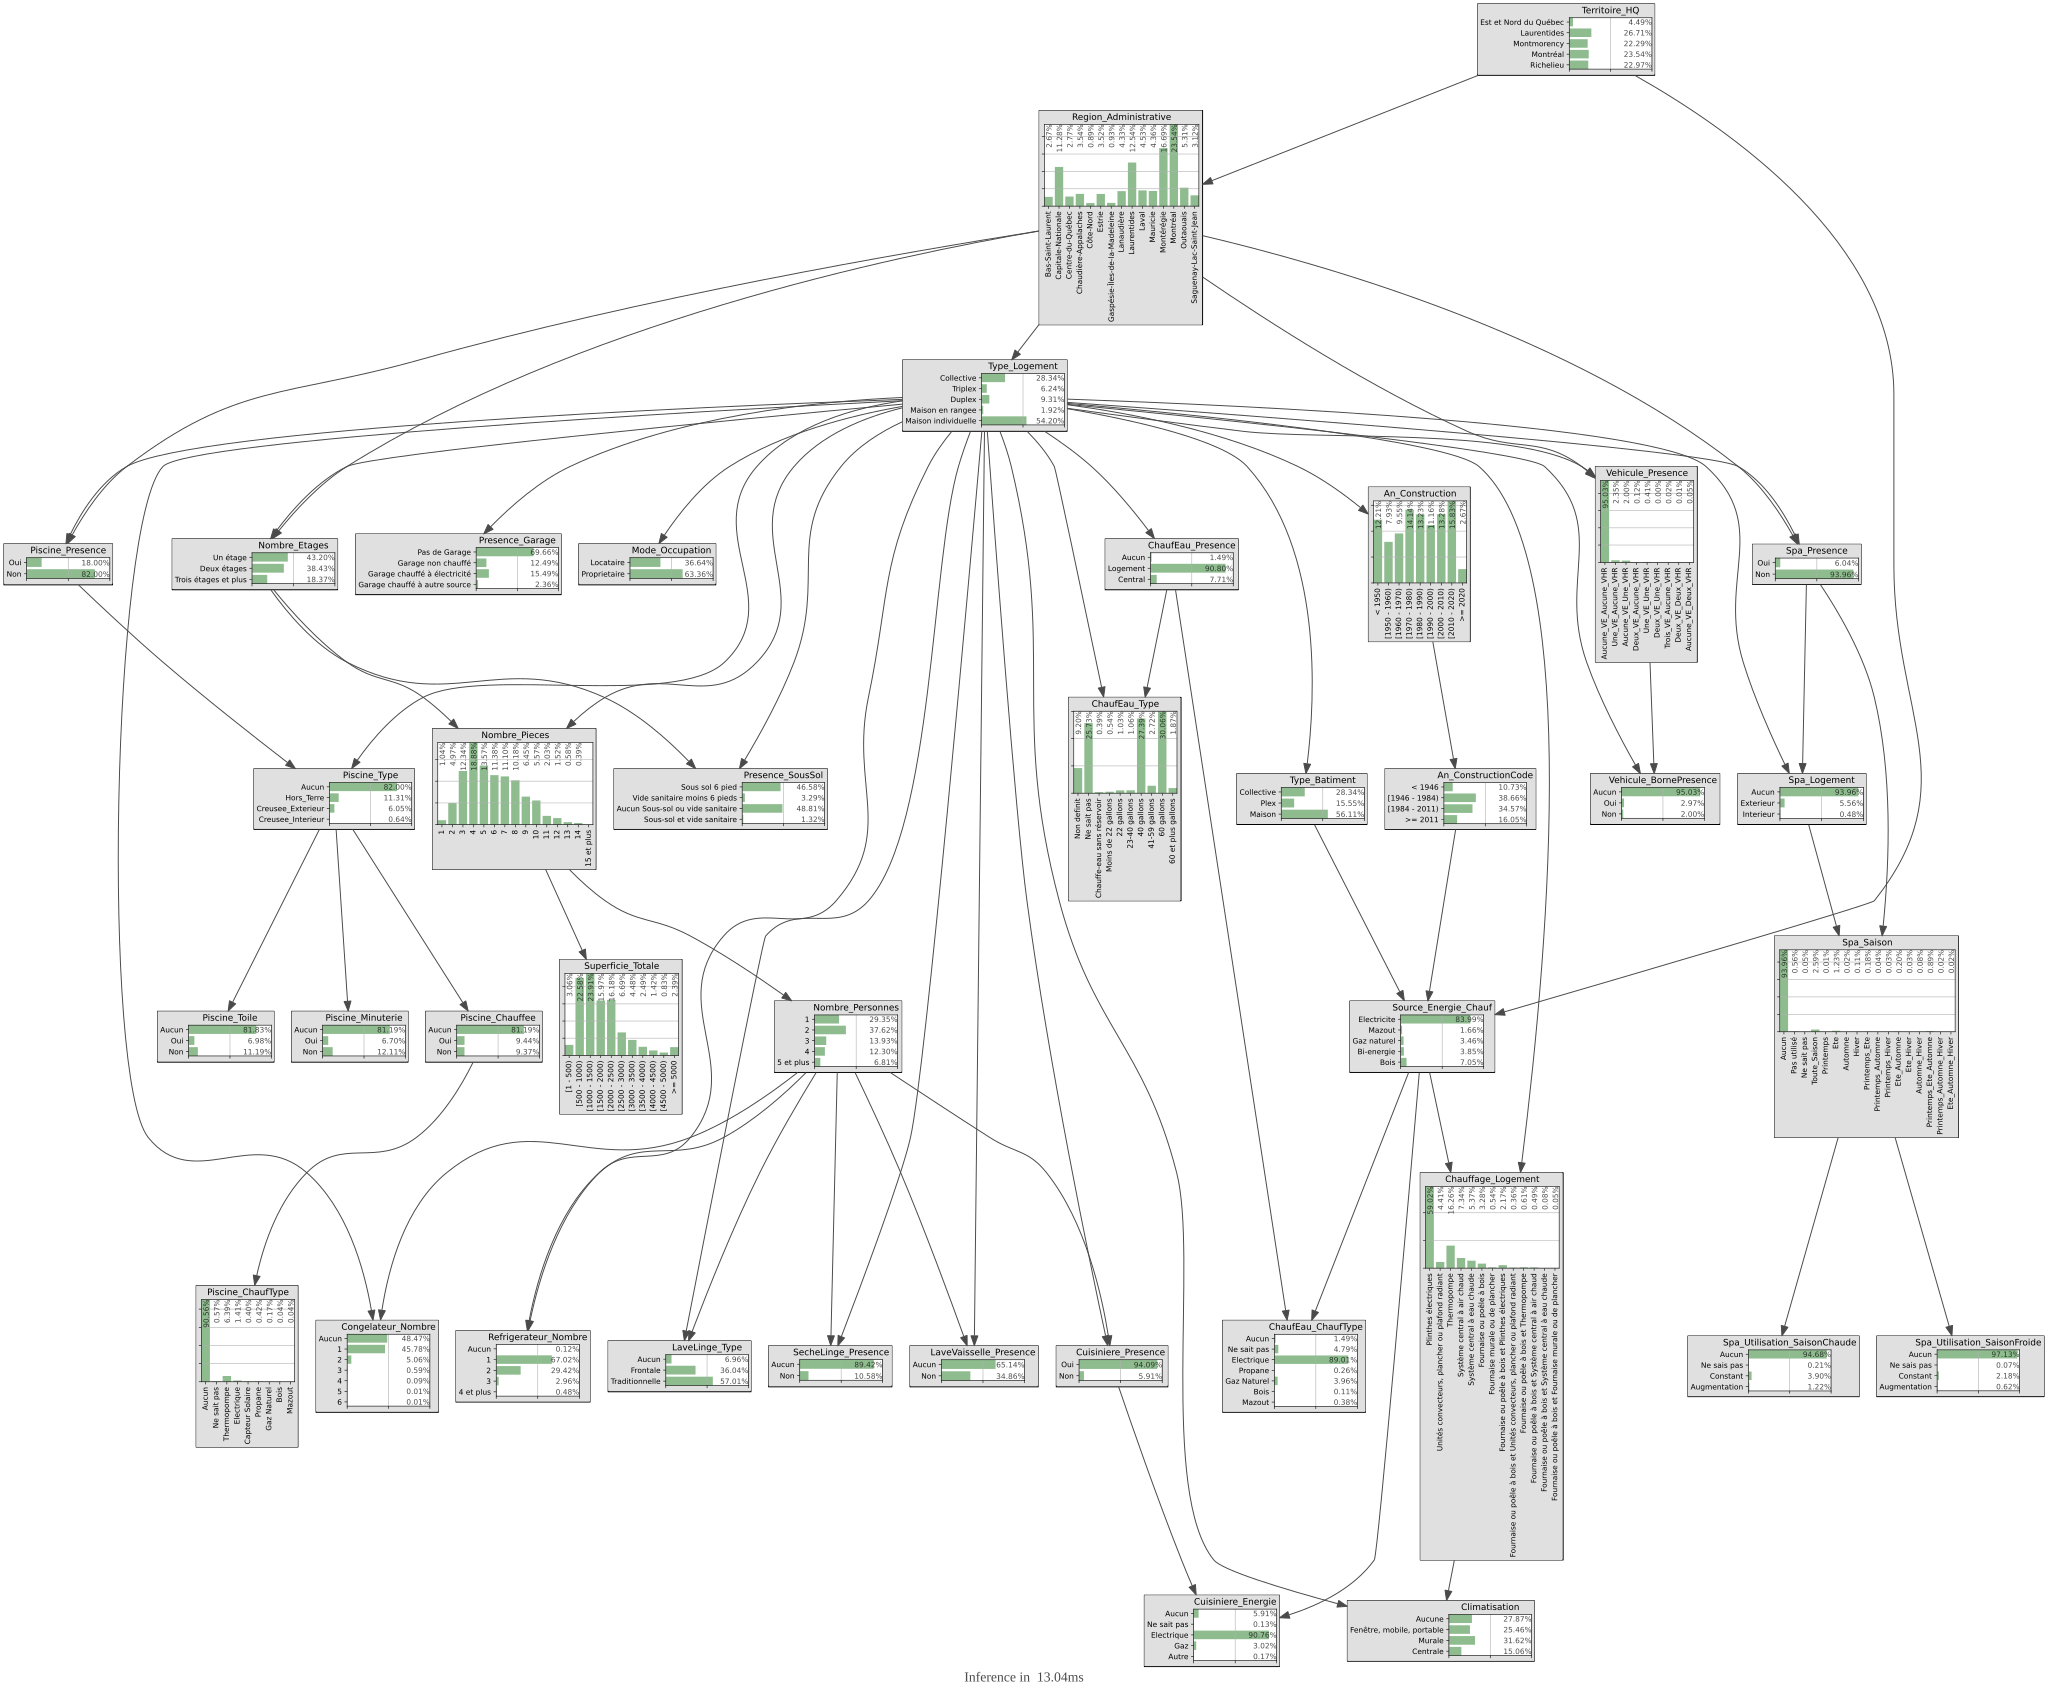

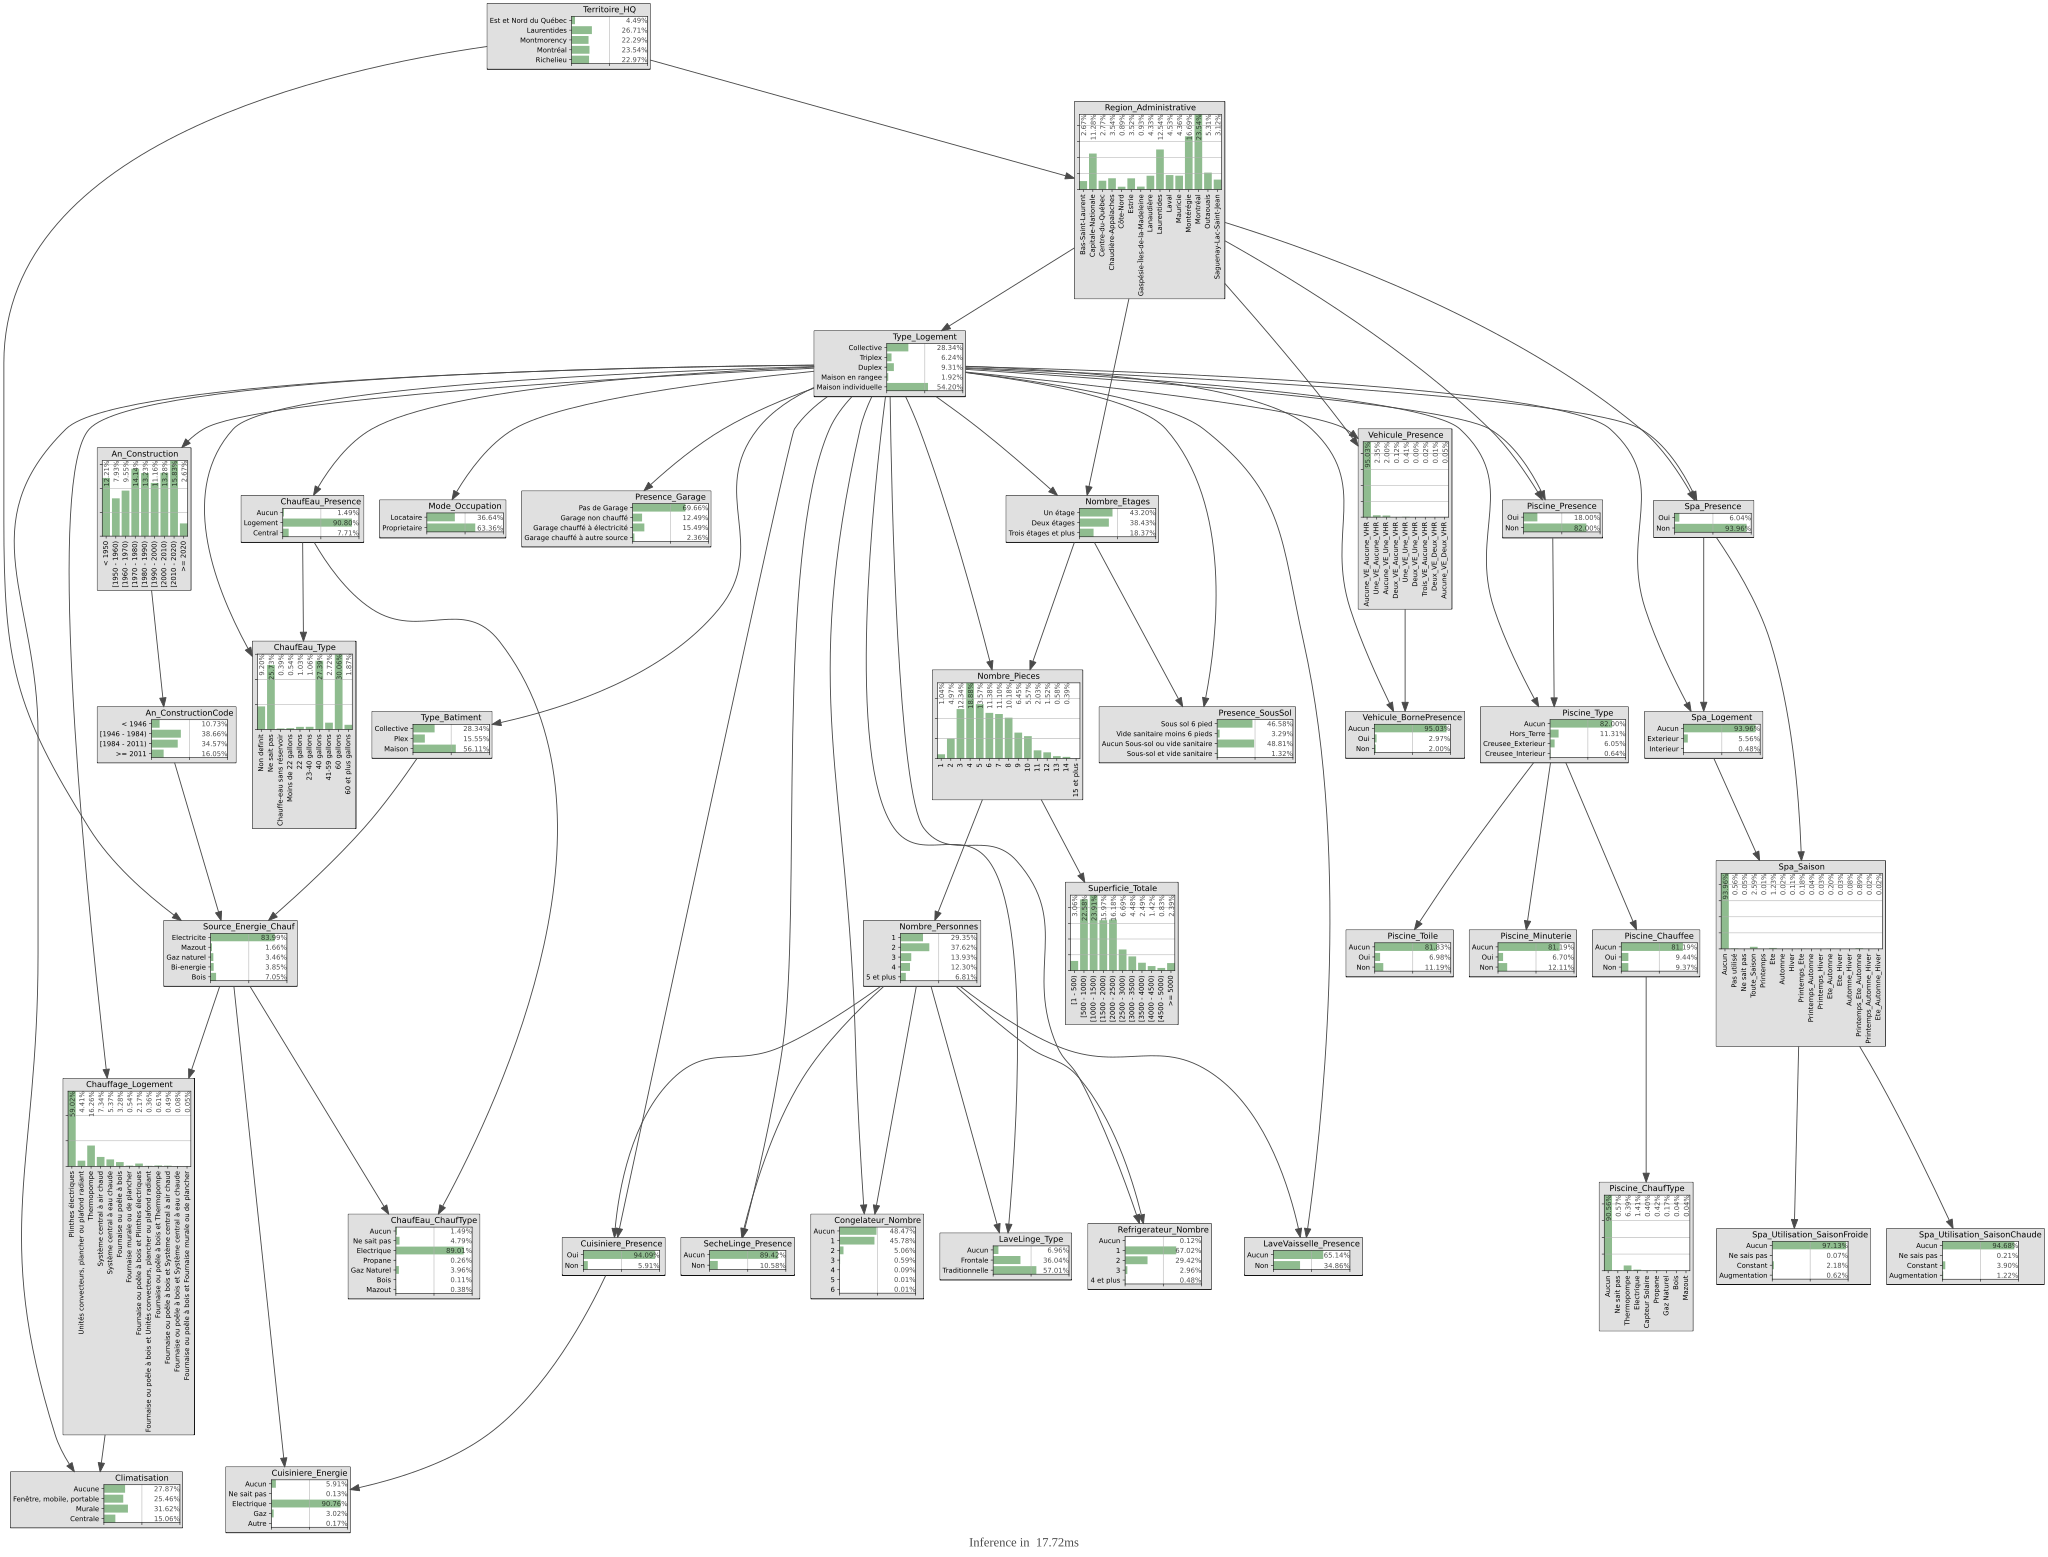

In [6]:
import pyagrum as gum
#import pyagrum.lib.ipython as gnb
import pyagrum.lib.notebook as gnb

# Load the Bayesian Network from the saved file
InsClsEUEMr_2 = EUEMr()
path = parent_dir+"/data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr_2.Load_BN(path)

# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={},size = '30')

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn,evs={},size = '30')

In [7]:
InsClsEUEMr.bn.cpt("ChaufEau_ChaufType")

(pyagrum.Tensor@000001FFEC206960) 
             ||  ChaufEau_ChaufType                                                 |
Source|ChaufE||Aucun    |Ne sait p|Electriqu|Propane  |Gaz Natur|Bois     |Mazout   |
------|------||---------|---------|---------|---------|---------|---------|---------|
Electr|Aucun || 1.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
Mazout|Aucun || 1.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
Gaz na|Aucun || 1.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
Bi-ene|Aucun || 1.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
Bois  |Aucun || 1.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |
Electr|Logeme|| 0.0000  | 0.0295  | 0.9614  | 0.0022  | 0.0066  | 0.0000  | 0.0003  |
[...3 more line(s) ...]
Bois  |Logeme|| 0.0000  | 0.0026  | 0.9757  | 0.0056  | 0.0000  | 0.0125  | 0.0036  |
Electr|Centra|| 0.0000  | 0.2965  | 0.6206  | 0.0000  | 0.0809  | 0.0000  | 0.0021  |
Mazout|Centra|| 0.0000  | 0.2293  | 0.2472  | 0.0000  | 0.0000  | 0.0000  | 0.5234  |
Gaz na|Centra|| 0.0000  | 0.2633  | 0.0580  | 0.0000  | 0.6787  | 0.0000  | 0.0000  |
Bi-ene|Centra|| 0.0000  | 0.1357  | 0.2731  | 0.0656  | 0.1978  | 0.0000  | 0.3277  |
Bois  |Centra|| 0.0000  | 0.2512  | 0.7488  | 0.0000  | 0.0000  | 0.0000  | 0.0000  |

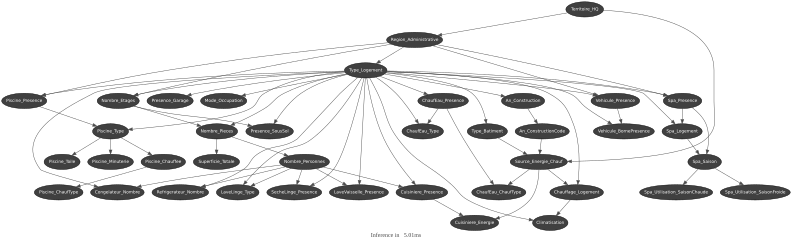

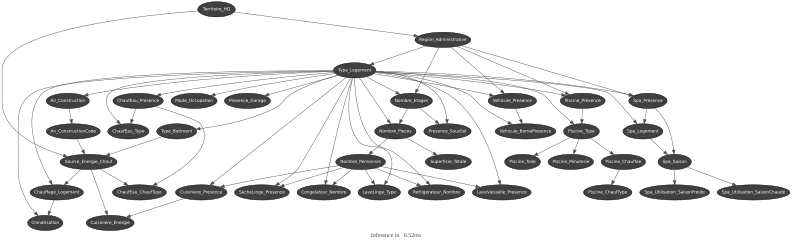

In [8]:
# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn, evs={}, targets={"AnConstruction"}, size="11")

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn, evs={}, targets={"AnConstruction"}, size="11")


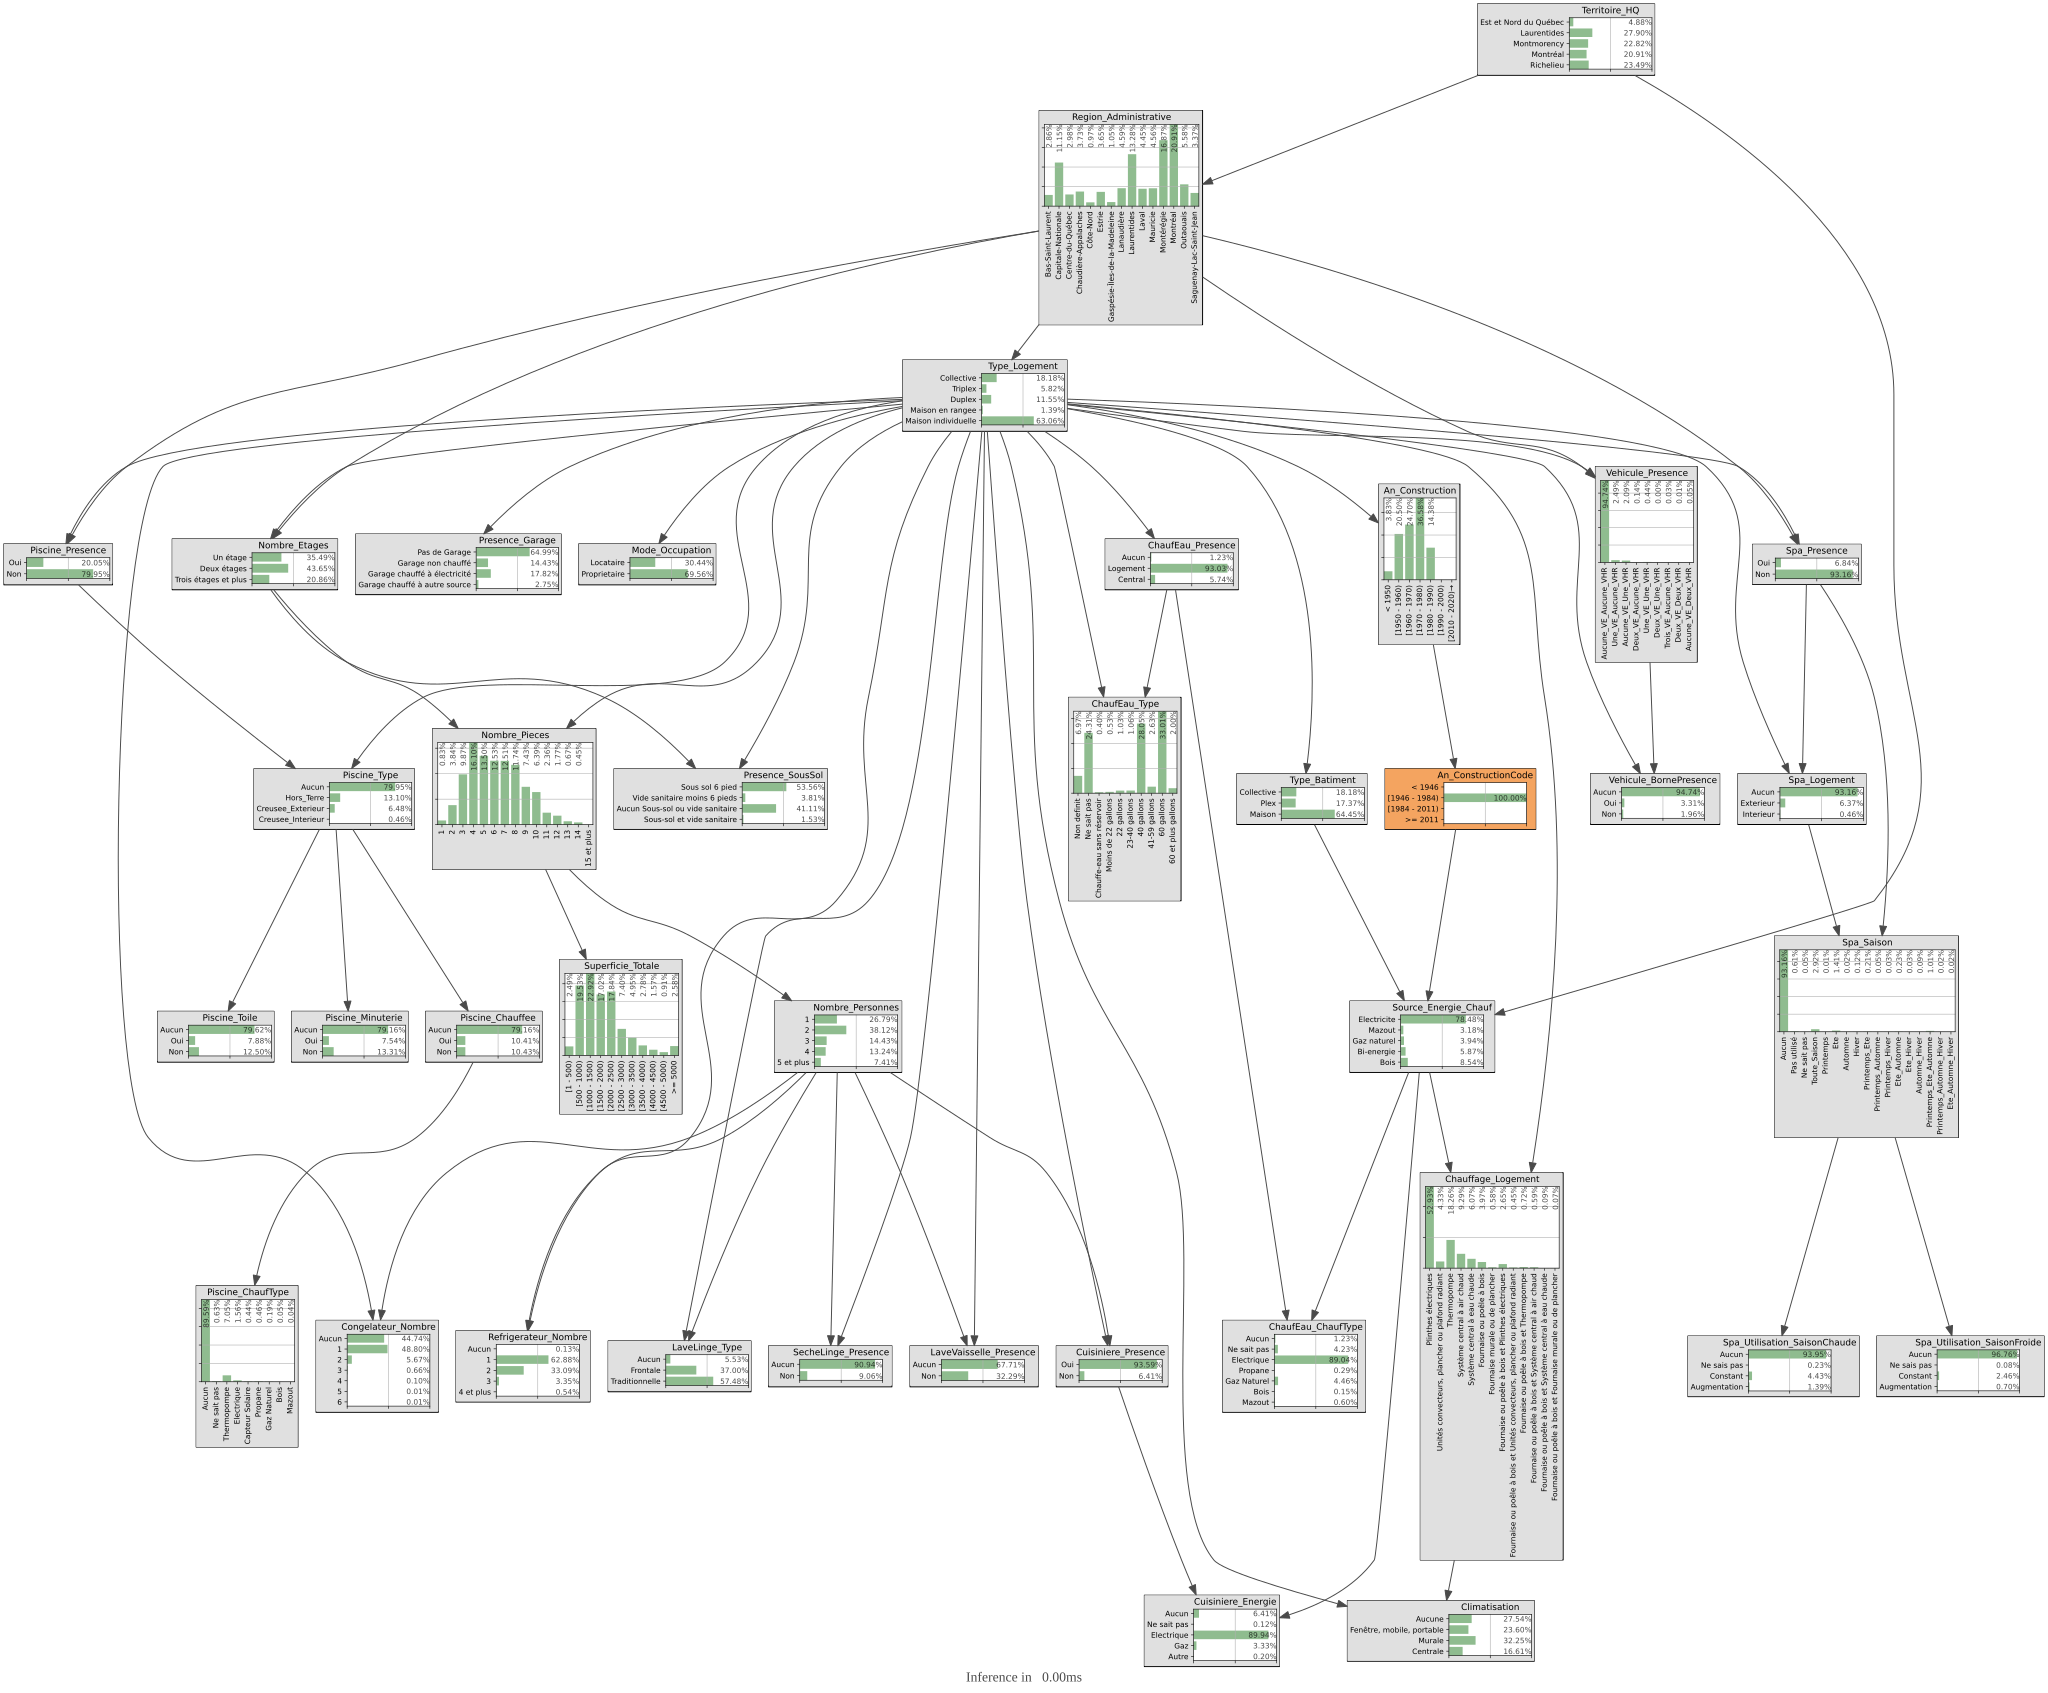

In [9]:
# Display the Bayesian Network with specific evidence - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={"An_ConstructionCode": "[1946 - 1984)"},size = '30')

# Display the Bayesian Network with specific evidence - Apres enregistrement
#gnb.showInference(InsClsEUEMr_2.bn,evs={"Mode_Occupation": "Proprietaire"},size = '30')


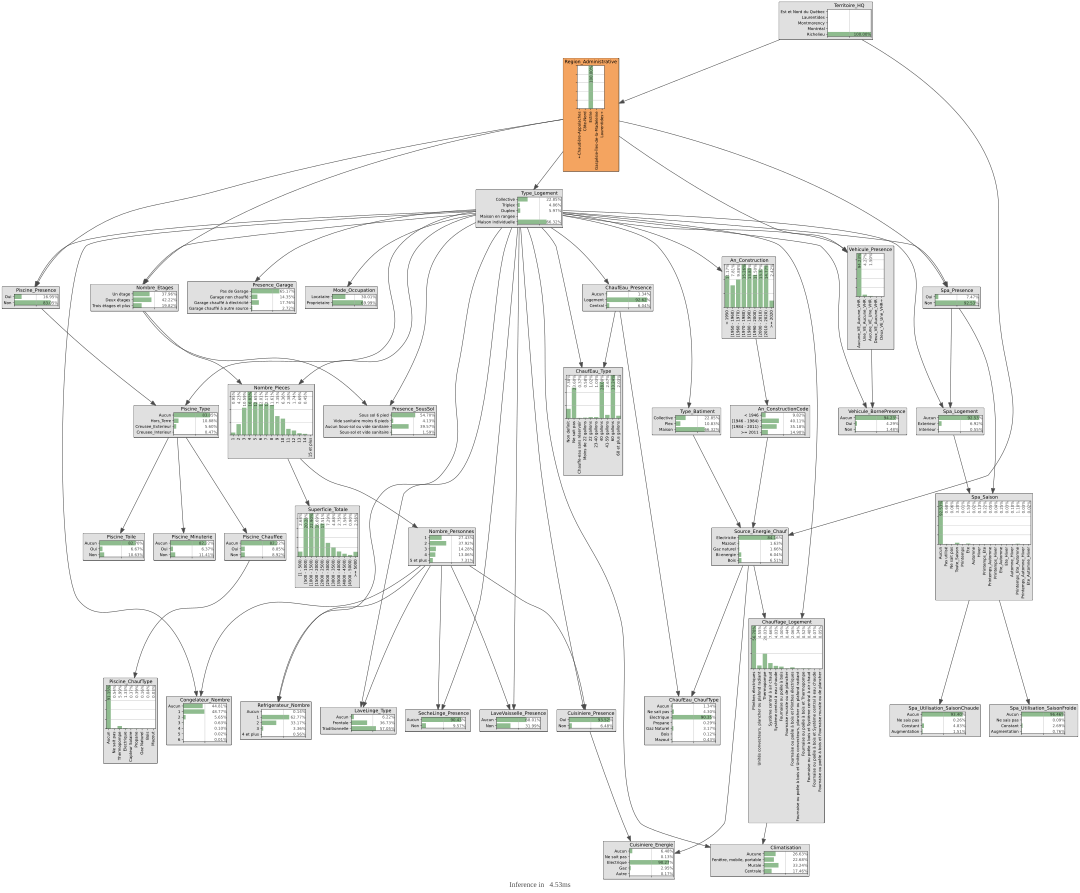

In [10]:
reg = ["Outaouais", "Laurentides", "Montréal", "Capitale-Nationale", "Mauricie", "Côte-Nord", "Chaudière-Appalaches", "Montérégie", "Estrie", "Centre-du-Québec", "Laval", "Lanaudière", "Saguenay-Lac-Saint-Jean", "Bas-Saint-Laurent", "Gaspésie-Îles-de-la-Madeleine"]
gnb.showInference(InsClsEUEMr.bn,evs={"Region_Administrative": reg[8]},size = '15')

In [11]:
Nombre_de_Samples = 3
Evidence = {"Mode_Occupation": "Proprietaire"}

# Fait un échantillonage - Avant enregistrement
df1 = InsClsEUEMr.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Fait un échantillonage - Apres enregistrement
df2 = InsClsEUEMr_2.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Affiche les échantillons - Avant enregistrement
df1, df2

(  Territoire_HQ Region_Administrative        Type_Logement ChaufEau_Presence  \
 0     Richelieu            Montérégie  Maison individuelle          Logement   
 1     Richelieu                Estrie  Maison individuelle          Logement   
 2   Montmorency  Chaudière-Appalaches  Maison individuelle          Logement   
 
   ChaufEau_Type Mode_Occupation         Nombre_Etages Nombre_Pieces  \
 0    60 gallons    Proprietaire           Deux étages             8   
 1    60 gallons    Proprietaire  Trois étages et plus             6   
 2    40 gallons    Proprietaire           Deux étages             7   
 
   Superficie_Totale Nombre_Personnes  ... Spa_Logement Spa_Saison  \
 0     [2500 - 3000)        5 et plus  ...        Aucun      Aucun   
 1     [1500 - 2000)                1  ...        Aucun      Aucun   
 2     [1000 - 1500)                4  ...        Aucun      Aucun   
 
   Spa_Utilisation_SaisonFroide Spa_Utilisation_SaisonChaude Piscine_Presence  \
 0                   

In [12]:
#proportion de valeur
# Fait un échantillonage - Apres enregistrement
df3 = InsClsEUEMr_2.do_Sampling(1000, evs = {})

for col in df2.columns:
    print(col + ":" + str(df3[col].value_counts()/ len(df3)))


Territoire_HQ:Territoire_HQ
Laurentides              0.295
Montréal                 0.240
Montmorency              0.210
Richelieu                0.207
Est et Nord du Québec    0.048
Name: count, dtype: float64
Region_Administrative:Region_Administrative
Montréal                         0.240
Montérégie                       0.148
Laurentides                      0.130
Capitale-Nationale               0.116
Laval                            0.064
Outaouais                        0.053
Lanaudière                       0.048
Mauricie                         0.037
Centre-du-Québec                 0.030
Bas-Saint-Laurent                0.030
Chaudière-Appalaches             0.030
Estrie                           0.029
Saguenay-Lac-Saint-Jean          0.027
Côte-Nord                        0.009
Gaspésie-Îles-de-la-Madeleine    0.009
Name: count, dtype: float64
Type_Logement:Type_Logement
Maison individuelle    0.534
Collective             0.261
Duplex                 0.104
Triplex          